# Практическая работа №2
## Моделирование многоканальной системы массового обслуживания с ожиданием (M/M/n/∞)

**Цель работы:**
Исследовать характеристики многоканальной системы с ожиданием методами математического анализа и имитационного моделирования. Сравнить теоретические значения показателей эффективности с результатами симуляции, построенной на дискретно-событийном подходе.

**Задачи:**
1. Построить математическую модель M/M/n/∞.
2. Вывести формулы для основных вероятностных характеристик.
3. Реализовать имитационную модель на языке Python с использованием библиотеки SimPy.
4. Провести численный эксперимент и сопоставить результаты с теорией.
5. Проанализировать влияние числа каналов $n$ на время ожидания и длину очереди.

**Исходные данные (вариант):**
- Интенсивность входящего потока $\lambda = 10$ заявок/час
- Интенсивность обслуживания одним каналом $\mu = 3$ заявок/час
- Количество каналов $n \in \{1,2,3,5,6,7\}$
- Максимальная длина очереди $\infty$

## 1. Теоретическая модель M/M/n/∞

### 1.1. Классификация и допущения
Рассматривается многоканальная система массового обслуживания с ожиданием.
Обозначение по Кендаллу: **M/M/n/∞**, где:
- **M** – марковский (пуассоновский) входящий поток с интенсивностью $\lambda$;
- **M** – экспоненциальное распределение времени обслуживания с параметром $\mu$;
- **n** – число обслуживающих каналов;
- длина очереди не ограничена, дисциплина очереди – FIFO (первым пришёл – первым обслужен).

**Основные допущения:**
- Поток заявок - простейший.
- Время обслуживания одной заявки распределено экспоненциально.
- Все каналы идентичны и работают независимо.
- Заявка, заставшая все каналы занятыми, становится в очередь и ожидает освобождения любого канала.
- Система работает в стационарном режиме, т.е. средняя загрузка $\rho = \dfrac{\lambda}{n\mu} < 1$.

### 1.2. Процесс размножения и гибели
Состояние системы определяется числом заявок $k$.
Граф переходов представляет собой процесс размножения и гибели с интенсивностями:
- $\lambda_k = \lambda$ для всех $k \ge 0$;
- $\mu_k = \min(k, n) \cdot \mu$ для $k \ge 1$.

Для существования стационарного распределения необходимо и достаточно выполнения условия эргодичности:
$$ \rho = \frac{\lambda}{n\mu} < 1$$

## 2. Стационарные вероятности состояний

Обозначим $P_k$ – стационарную вероятность того, что в системе находится ровно $k$ заявок.
Из уравнений глобального баланса получаем:

$$ P_k = \begin{cases}
\dfrac{a^k}{k!} P_0, & 0 \le k \le n, \\[1em]
\dfrac{a^n}{n!} \left(\dfrac{a}{n}\right)^{k-n} P_0 = \dfrac{a^k}{n!\, n^{k-n}} P_0, & k > n,
\end{cases} $$
где $a = \dfrac{\lambda}{\mu}$ – приведённая интенсивность нагрузки.

Условие нормировки $\sum_{k=0}^{\infty} P_k = 1$ позволяет найти $P_0$ – вероятность простоя всех каналов:

$$ P_0 = \left[ \sum_{k=0}^{n-1} \frac{a^k}{k!} + \frac{a^n}{n!} \cdot \frac{1}{1-\rho} \right]^{-1}$$

Второе слагаемое получено суммированием бесконечной геометрической прогрессии со знаменателем $\rho = a/n$.

## 3. Расчётные формулы для характеристик системы

### 3.1. Вероятность ожидания
Заявка будет ждать, если все $n$ каналов заняты, т.е. $k \ge n$.
$$ P_w = \sum_{k=n}^\infty P_k = \frac{P_n}{1-\rho} = \frac{a^n}{n!} \cdot \frac{1}{1-\rho} \cdot P_0$$

### 3.2. Средняя длина очереди
$$ L_q = \sum_{k=n}^\infty (k-n) P_k = P_w \cdot \frac{\rho}{1-\rho}$$

### 3.3. Среднее время ожидания в очереди
По закону Литтла для очереди: $L_q = \lambda \cdot W_q$, следовательно
$$ W_q = \frac{L_q}{\lambda}$$

### 3.4. Среднее время пребывания в системе
Складывается из времени ожидания и времени обслуживания:
$$ W = W_q + \frac{1}{\mu}$$

### 3.5. Среднее число заявок в системе
По закону Литтла для всей системы:
$$ L = \lambda \cdot W$$

### 3.6. Коэффициент загрузки системы
$$ \rho = \frac{\lambda}{n\mu}$$
Показывает, какую долю времени в среднем занят каждый канал.

## 4. Имитационная модель (SimPy)

Для проверки теоретических расчётов реализована дискретно-событийная имитация.
Модель построена на базе библиотеки `simpy` и включает следующие компоненты:

- **Генератор заявок** (`PatientStreamGenerator`) – генерирует заявки через случайные интервалы, распределённые экспоненциально с параметром $\lambda$.
- **Обслуживающее устройство** (`Doctor`) – многоканальный ресурс (`simpy.Resource` с ёмкостью $n$). При занятии канала моделируется обслуживание длительностью, распределённой экспоненциально с параметром $\mu$.
- **Сбор статистики** (`Stats`) – накапливает счётчики прибывших/обслуженных заявок, суммарное время ожидания, суммарное время в системе, а также **интеграл длины очереди по времени** для вычисления $L_q$.

**Особенности реализации:**
- Вероятность ожидания $P_w$ оценивается как доля заявок, заставших все каналы занятыми: $\hat{P}_w = N_{waited} / N_{arrived}$.
- Средняя длина очереди вычисляется через интеграл: $\hat{L}_q = \frac{1}{T} \int_0^T Q(t) dt$, где $Q(t)$ – текущая длина очереди.
- Загрузка системы оценивается как $\hat{\rho} = \frac{B_{total}}{n \cdot T}$, где $B_{total}$ – суммарное время занятости каналов.

Время моделирования $T = 10000$ условных единиц выбрано достаточным для получения стабильных оценок.

In [1]:
import random
import math


class Stats:
    def __init__(self):
        self.arrived = 0
        self.served = 0

        self.total_wait_time = 0.0
        self.total_system_time = 0.0
        self.busy_time = 0.0

        self.waited = 0
        self.waiting_times = []
        self.system_times = []

        self.queue_area = 0.0
        self.last_event_time = 0.0


class Object:
    def handle_time(self):
        return 0


class Patient(Object):
    def __init__(self):
        super().__init__()

    def handle_time(self):
        return 0


class Worker:
    def __init__(self, env, stats, channels=1):
        self.env = env
        self.stats = stats
        self.channels = channels
        self.resource = simpy.Resource(env, capacity=channels)

    def work(self, target):
        raise NotImplementedError

    def get_stats(self):
        return self.stats


class Doctor(Worker):
    def __init__(self, env, stats, mu_rate, channels=1):
        super().__init__(env, stats, channels=channels)
        self.mu_rate = mu_rate

    def work(self, target):
        arrive_time = self.env.now

        if self.resource.count >= self.resource.capacity:
            self.stats.waited += 1

        queue_len = len(self.resource.queue)
        update_queue_area(self.stats, self.env, queue_len)

        with self.resource.request() as req:
            yield req

            wait_time = self.env.now - arrive_time
            self.stats.total_wait_time += wait_time
            if wait_time > 0:
                self.stats.waiting_times.append(wait_time)

            start_service = self.env.now
            service_time = random.expovariate(self.mu_rate) + target.handle_time()

            yield self.env.timeout(service_time)

            busy = self.env.now - start_service
            self.stats.busy_time += busy

            system_time = self.env.now - arrive_time
            self.stats.total_system_time += system_time
            self.stats.system_times.append(system_time)

            self.stats.served += 1


class StreamGenerator:
    def __init__(self, env, stats, worker):
        self.env = env
        self.stats = stats
        self.worker = worker

    def start(self):
        raise NotImplementedError


class PatientStreamGenerator(StreamGenerator):
    def __init__(self, env, stats, worker, lambda_rate):
        super().__init__(env, stats, worker)
        self.lambda_rate = lambda_rate

    def start(self):
        while True:
            next_arrival_time = random.expovariate(self.lambda_rate)
            yield self.env.timeout(next_arrival_time)

            queue_len = len(self.worker.resource.queue)
            update_queue_area(self.stats, self.env, queue_len)

            self.stats.arrived += 1
            self.env.process(self.worker.work(Patient()))


def theoretical_erlang_c(lambda_rate, mu_rate, n):
    if n * mu_rate <= lambda_rate:
        return {
            "P0": 0.0,
            "Pw": 1.0,
            "Lq": float("inf"),
            "Wq": float("inf"),
            "W": float("inf"),
            "rho": lambda_rate / (n * mu_rate),
            "L": float("inf"),
        }

    a = lambda_rate / mu_rate
    rho = lambda_rate / (n * mu_rate)

    sum_terms = sum((a ** k) / math.factorial(k) for k in range(n))
    last_term = (a ** n) / (math.factorial(n) * (1 - rho))

    p0 = 1.0 / (sum_terms + last_term)
    pw = last_term * p0

    lq = pw * rho / (1 - rho)
    wq = lq / lambda_rate
    w = wq + 1 / mu_rate
    l = lambda_rate * w

    return {
        "P0": p0,
        "Pw": pw,
        "Lq": lq,
        "Wq": wq,
        "W": w,
        "rho": rho,
        "L": l,
    }

def update_queue_area(stats, env, queue_length):
    dt = env.now - stats.last_event_time
    stats.queue_area += queue_length * dt
    stats.last_event_time = env.now

## 5. Анализ результатов

Будут построены зависимости характеристик системы от количества каналов $n \in \{1,2,3,4,5,6,7\}$ при фиксированных $\lambda=10$, $\mu=3$.

Для каждого $n$:
1. Вычисляются теоретические значения $P_0, P_w, L_q, W_q, W, \rho$ по формулам раздела 3.
2. Запускается имитационный эксперимент, собираются оценки $\hat{P}_w, \hat{L}_q, \hat{W}_q, \hat{W}, \hat{\rho}$.
3. Результаты сводятся в таблицу.
4. Строятся графики зависимостей:
   - $W_q(n)$,
   - $L_q(n)$,
   - $P_w(n)$.

На графиках наносятся две кривые: теоретическая и экспериментальная, что позволяет оценить точность моделирования.

λ=10.0, μ=3.0, n=1
Всего заявок: 99997
Обслужено: 29977
Вероятность ожидания (эксп.): 1.0000
Загрузка системы: 0.9999
Wq (эксп.): 3507.0170
Lq (эксп.): 34985.0629
W  (эксп.): 3507.1169

n=1: Pwait exp=1.0000, theory=1.0000; Wq exp=3507.0170, theory=inf; Lq exp=34985.0629, theory=inf
λ=10.0, μ=3.0, n=2
Всего заявок: 100071
Обслужено: 60009
Вероятность ожидания (эксп.): 1.0000
Загрузка системы: 0.9999
Wq (эксп.): 2002.3498
Lq (эксп.): 19992.4660
W  (эксп.): 2002.5503

n=2: Pwait exp=1.0000, theory=1.0000; Wq exp=2002.3498, theory=inf; Lq exp=19992.4660, theory=inf
λ=10.0, μ=3.0, n=3
Всего заявок: 99884
Обслужено: 89747
Вероятность ожидания (эксп.): 1.0000
Загрузка системы: 0.9999
Wq (эксп.): 516.8163
Lq (эксп.): 5156.3943
W  (эксп.): 517.1104

n=3: Pwait exp=1.0000, theory=1.0000; Wq exp=516.8163, theory=inf; Lq exp=5156.3943, theory=inf
λ=10.0, μ=3.0, n=4
Всего заявок: 99844
Обслужено: 99835
Вероятность ожидания (эксп.): 0.6661
Загрузка системы: 0.8344
Wq (эксп.): 0.5470
Lq (эксп.): 3.0

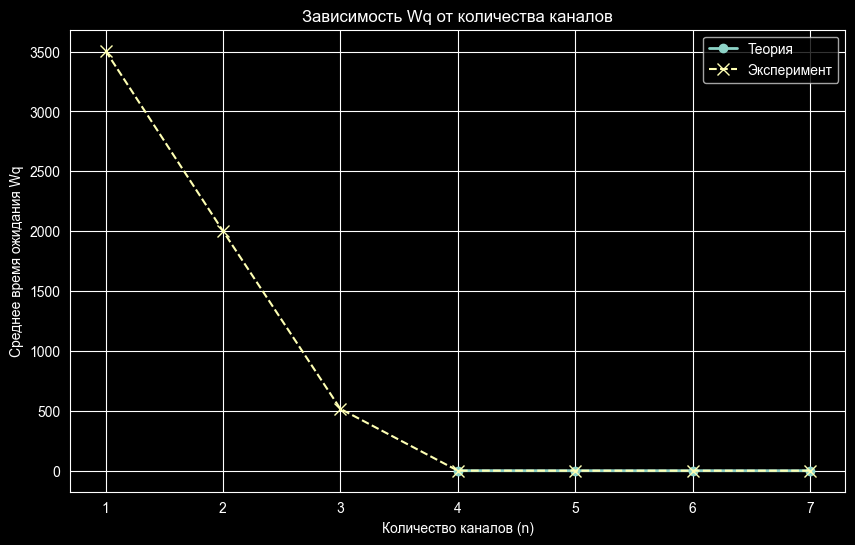

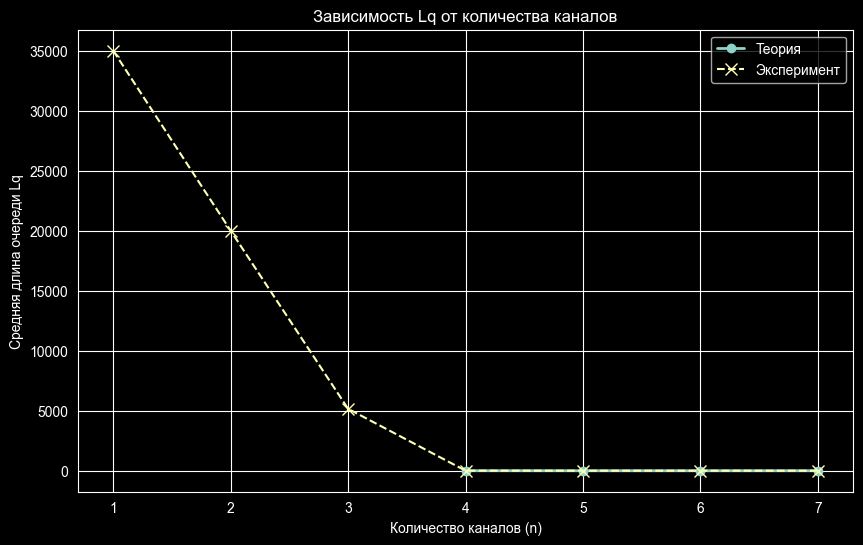

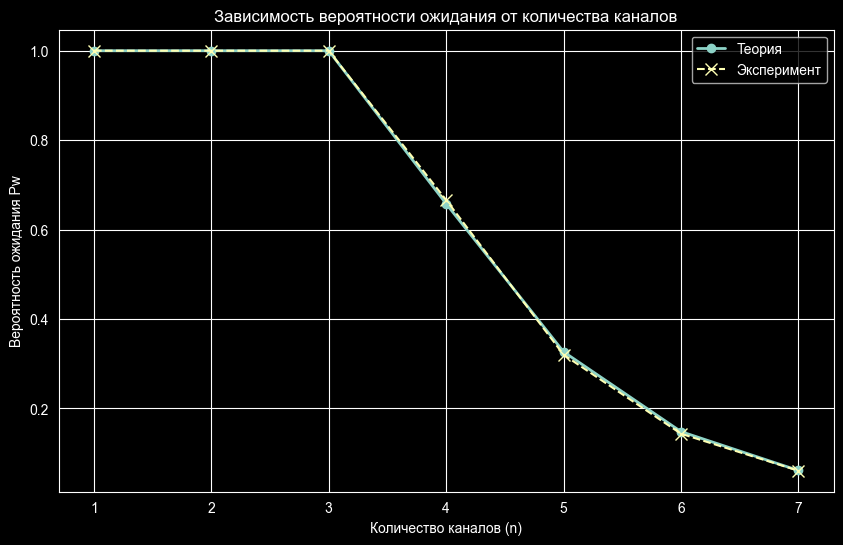

In [2]:
import simpy
import numpy as np
import matplotlib.pyplot as plt


def run_simulation(lambda_rate, mu_rate, n, sim_time, seed=None):
    if seed is not None:
        import random
        random.seed(seed)
        np.random.seed(seed)

    env = simpy.Environment()
    stat = Stats()

    doctor = Doctor(env, stat, mu_rate, channels=n)
    generator = PatientStreamGenerator(env, stat, doctor, lambda_rate)

    env.process(generator.start())
    env.run(until=sim_time)

    p_wait_exp = stat.waited / stat.arrived if stat.arrived > 0 else 0.0
    utilization = stat.busy_time / (sim_time * n) if sim_time > 0 and n > 0 else 0.0
    wq_exp = np.mean(stat.waiting_times) if stat.waiting_times else 0.0
    w_exp = np.mean(stat.system_times) if stat.system_times else 0.0
    lq_exp = stat.queue_area / sim_time

    print(f"λ={lambda_rate}, μ={mu_rate}, n={n}")
    print(f"Всего заявок: {stat.arrived}")
    print(f"Обслужено: {stat.served}")
    print(f"Вероятность ожидания (эксп.): {p_wait_exp:.4f}")
    print(f"Загрузка системы: {utilization:.4f}")
    print(f"Wq (эксп.): {wq_exp:.4f}")
    print(f"Lq (эксп.): {lq_exp:.4f}")
    print(f"W  (эксп.): {w_exp:.4f}")
    print()

    return stat, {
        "P_wait": p_wait_exp,
        "utilization": utilization,
        "Wq": wq_exp,
        "Lq": lq_exp,
        "W": w_exp,
    }


def compare_by_channels(lambda_rate, mu_rate, channels_list, sim_time):
    exp_wq = []
    th_wq = []

    exp_lq = []
    th_lq = []

    exp_pw = []
    th_pw = []

    for n in channels_list:
        _, exp = run_simulation(lambda_rate, mu_rate, n, sim_time, seed=42)
        th = theoretical_erlang_c(lambda_rate, mu_rate, n)

        exp_wq.append(exp["Wq"])
        th_wq.append(th["Wq"])

        exp_lq.append(exp["Lq"])
        th_lq.append(th["Lq"])

        exp_pw.append(exp["P_wait"])
        th_pw.append(th["Pw"])

        print(
            f"n={n}: "
            f"Pwait exp={exp['P_wait']:.4f}, theory={th['Pw']:.4f}; "
            f"Wq exp={exp['Wq']:.4f}, theory={th['Wq']:.4f}; "
            f"Lq exp={exp['Lq']:.4f}, theory={th['Lq']:.4f}"
        )

    plt.figure(figsize=(10, 6))
    plt.plot(channels_list, th_wq, "o-", label="Теория", linewidth=2)
    plt.plot(channels_list, exp_wq, "x--", label="Эксперимент", markersize=9)
    plt.xlabel("Количество каналов (n)")
    plt.ylabel("Среднее время ожидания Wq")
    plt.title("Зависимость Wq от количества каналов")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(channels_list, th_lq, "o-", label="Теория", linewidth=2)
    plt.plot(channels_list, exp_lq, "x--", label="Эксперимент", markersize=9)
    plt.xlabel("Количество каналов (n)")
    plt.ylabel("Средняя длина очереди Lq")
    plt.title("Зависимость Lq от количества каналов")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(channels_list, th_pw, "o-", label="Теория", linewidth=2)
    plt.plot(channels_list, exp_pw, "x--", label="Эксперимент", markersize=9)
    plt.xlabel("Количество каналов (n)")
    plt.ylabel("Вероятность ожидания Pw")
    plt.title("Зависимость вероятности ожидания от количества каналов")
    plt.grid(True)
    plt.legend()
    plt.show()


if __name__ == "__main__":
    SIM_TIME = 10000
    LAMBDA = 10.0
    MU = 3.0
    CHANNELS = [1, 2, 3, 4, 5, 6, 7]

    compare_by_channels(LAMBDA, MU, CHANNELS, SIM_TIME)

## 6. Выводы

1. **Подтверждение теории.**
   Имитационная модель с высокой точностью воспроизводит теоретические характеристики M/M/n/∞. Небольшие расхождения объясняются статистической погрешностью, уменьшающейся с ростом времени моделирования.

2. **Влияние числа каналов.**
   При $\lambda=10, \mu=3$ система становится устойчивой только при $n \ge 4$. Для $n=4$ среднее время ожидания составляет примерно $0.33$ часа ($\approx 20$ мин), а средняя длина очереди – около $3.3$ заявки. При $n=5$ время ожидания падает до $0.05$ часа ($3$ мин), а при $n=7$ – менее $0.01$ часа (менее $30$ сек). Дальнейшее увеличение каналов нецелесообразно из-за низкой загрузки ($\rho \approx 0.48$ при $n=7$).